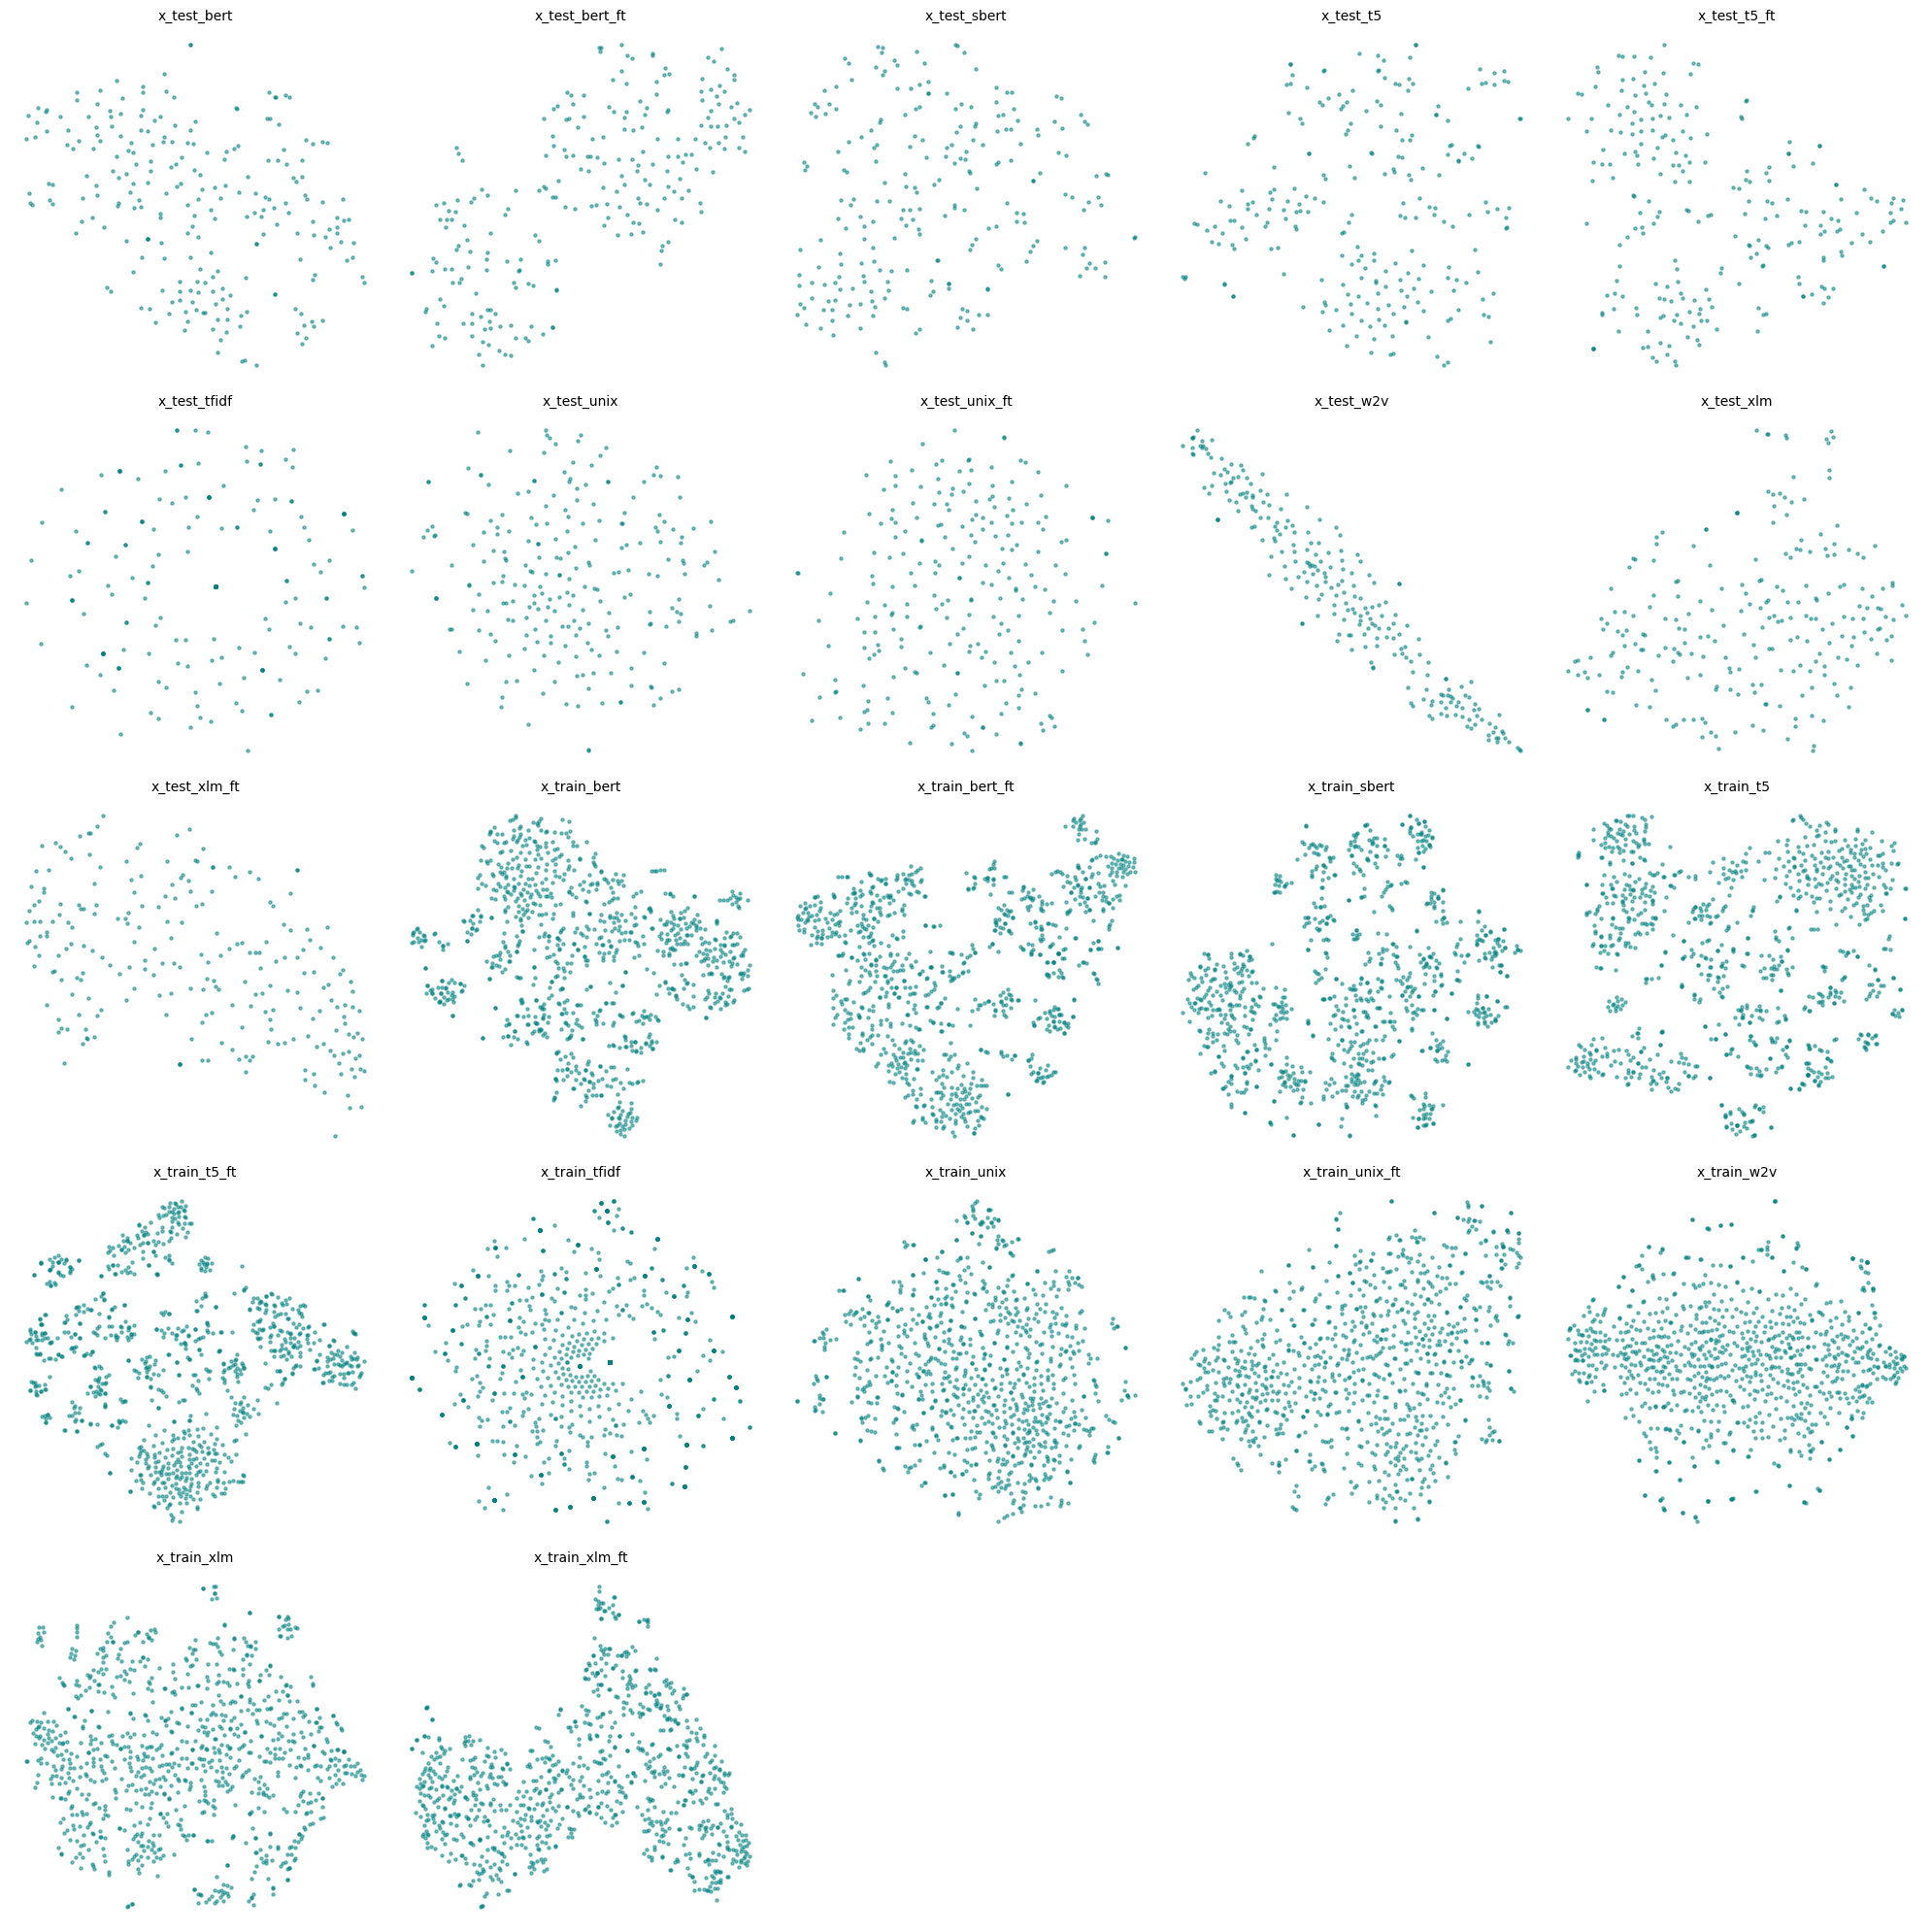

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os

file_list = sorted([f for f in os.listdir() if f.endswith('.npy')])
n_files = len(file_list)

# Calculate grid size (e.g., 5 rows, 5 columns for 22 files)
cols = 5
rows = (n_files // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, file_name in enumerate(file_list):
    data = np.load(file_name)
    
    # Flatten if it's 3D (samples, 1, features) -> (samples, features)
    if len(data.shape) > 2:
        data = data.reshape(data.shape[0], -1)
        
    # Run t-SNE for this specific file
    # We use a small perplexity in case your file has few samples
    perp = min(30, data.shape[0] - 1)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    proj = tsne.fit_transform(data)
    
    # Plot on the specific subplot
    axes[i].scatter(proj[:, 0], proj[:, 1], s=5, alpha=0.5, c='teal')
    axes[i].set_title(file_name.replace('.npy', ''), fontsize=10)
    axes[i].axis('off')

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()